In [1]:
import numpy as np
from forward_propagater import *
from input_writer import glowDischargeConfigs

import matplotlib.pyplot as plt
%matplotlib inline

## Write an bolsig input file with a standard LXCat cross section dataset

In [2]:
inputFile = 'input.test.dat'
config = glowDischargeConfigs['reaction300K'] # this is bolsig solver option configuration.
crsFile = './crs/Biagi.txt'
outputFile = 'output.test.dat'
writeInputFile(inputFile, config, crsFile, outputFile, noscreen=False)

## Run bolsig with this input file

In [3]:
import subprocess
command = "./bolsigminus %s" %(inputFile)

subprocess.check_call(command,shell=True)

READCOLLISIONS
 Ar
./crs/Biagi.txt
 C1    Ar    Elastic                                             
 C2    Ar    Excitation    11.55 eV                              
 C3    Ar    Excitation    11.62 eV                              
 C4    Ar    Excitation    11.72 eV                              
 C5    Ar    Excitation    11.83 eV                              
 C6    Ar    Excitation    12.91 eV                              
 C7    Ar    Excitation    13.08 eV                              
 C8    Ar    Excitation    13.10 eV                              
 C9    Ar    Excitation    13.15 eV                              
 C10   Ar    Excitation    13.17 eV                              
 C11   Ar    Excitation    13.27 eV                              
 C12   Ar    Excitation    13.28 eV                              
 C13   Ar    Excitation    13.30 eV                              
 C14   Ar    Excitation    13.33 eV                              
 C15   Ar    Excitation    13.48 eV      

0

## Read reaction coefficient from bolsig output

Default input variable is set to be electron mean energy (eV).

In [4]:
collisionTypes = ['Ionization'] + 4 * ['Excitation']
collisionEnergies = [15.76, 11.55, 11.62, 11.72, 11.83]
deltaE = 0.05

rateTables = []
for k, colType in enumerate(collisionTypes):
    rateTables += [np.copy(getReactionFromBolsig(outputFile, colType, collisionEnergies[k], deltaERange = deltaE))]

Input variable: Mean energy (eV)
Output collision type: Ionization
Output reaction energy: 1.57600000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.15500000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.16200000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.17200000E+01
Input variable: Mean energy (eV)
Output collision type: Excitation
Output reaction energy: 1.18300000E+01


Text(0, 0.5, 'Reaction rate coefficient ($m^3/s$)')

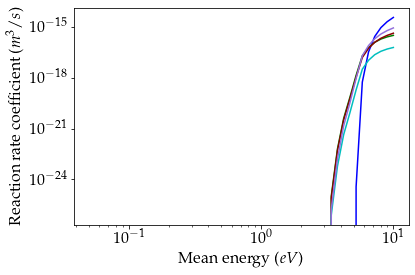

In [5]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
colors = ['b','g','darkred','c','mediumpurple','tomato']

plt.figure(1)
for k in range(5):
    plt.loglog(rateTables[k][:,0], rateTables[k][:,1], '-', color=colors[k])
plt.xlabel('Mean energy ($eV$)')
plt.ylabel('Reaction rate coefficient ($m^3/s$)')